In [6]:
!pip install shap xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. Load Data
df = pd.read_csv('train.csv')

# 2. THE FIX: Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("✅ Data Loaded and Column Names Cleaned!")
print("Cleaned Columns:", df.columns.tolist())

✅ Data Loaded and Column Names Cleaned!
Cleaned Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


❌ Error: 'loan_status' column not found. Check the list above!


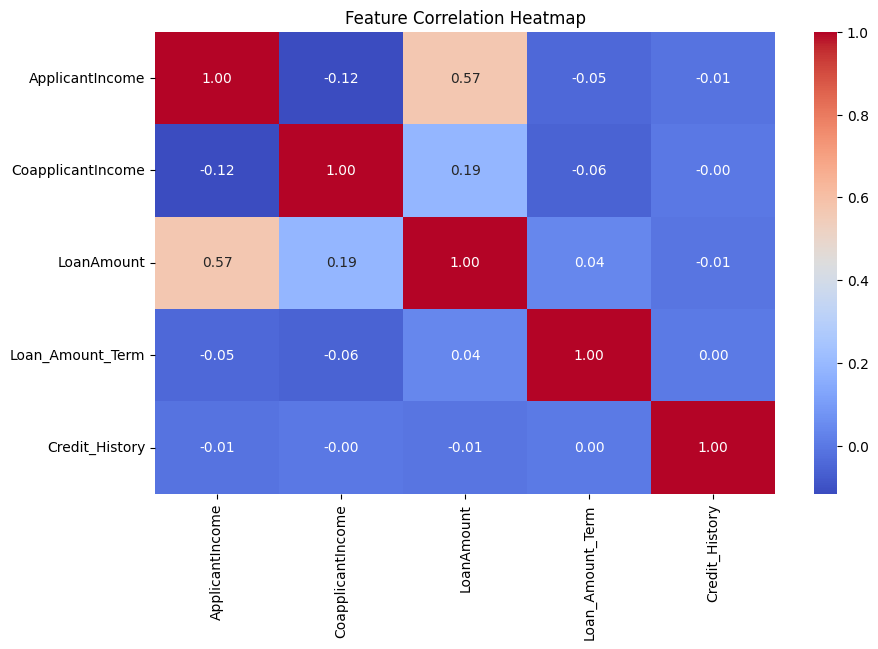

In [7]:
# Check if 'loan_status' exists
if 'loan_status' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='loan_status', data=df, palette='magma')
    plt.title('Loan Approval Distribution (0 = Rejected, 1 = Approved)')
    plt.show()
else:
    print("❌ Error: 'loan_status' column not found. Check the list above!")

# Show correlation between features
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
# 1. Standardize all column names: Remove spaces AND convert to lowercase
df.columns = df.columns.str.strip().str.lower()

print("Available columns now:", df.columns.tolist())

# 2. Check if 'loan_status' exists now
target_col = 'loan_status'

if target_col not in df.columns:
    # If not found, try to find a column that contains the word 'status'
    potential_targets = [c for c in df.columns if 'status' in c]
    if potential_targets:
        target_col = potential_targets[0]
        print(f"⚠️ 'loan_status' not found, using '{target_col}' instead.")
    else:
        raise KeyError("Could not find a target column with 'status' in the name. Please check your column names!")

# 3. Handle Categorical Data
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 4. Define Features (X) and Target (y)
X = df.drop(columns=[target_col])

# Drop ID columns if they exist (they confuse the AI)
if 'loan_id' in X.columns:
    X = X.drop(columns=['loan_id'])

y = df[target_col]

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train XGBoost
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# 7. Evaluate
y_pred = model.predict(X_test)
print(f"\n✅ Model Training Complete! Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Available columns now: ['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history', 'property_area', 'loan_status']

✅ Model Training Complete! Accuracy: 75.61%


Summary Plot: Which features matter most globally?


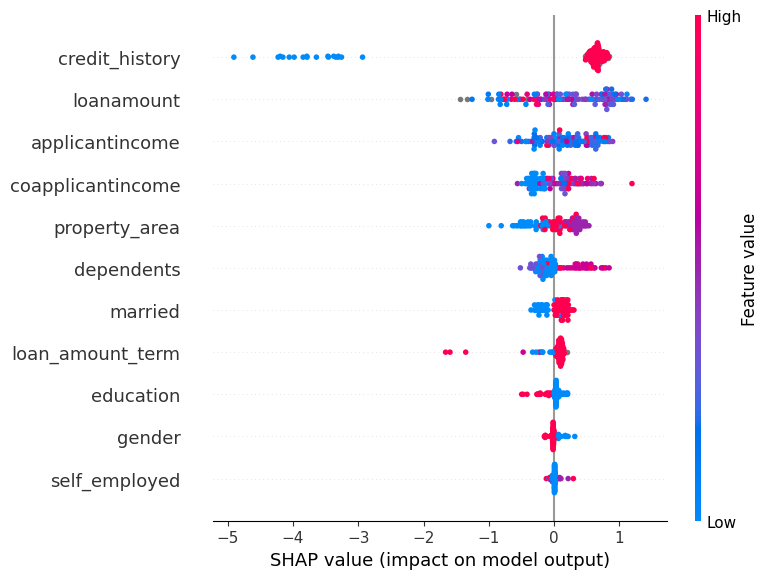


Waterfall Plot: Explaining a specific loan decision...


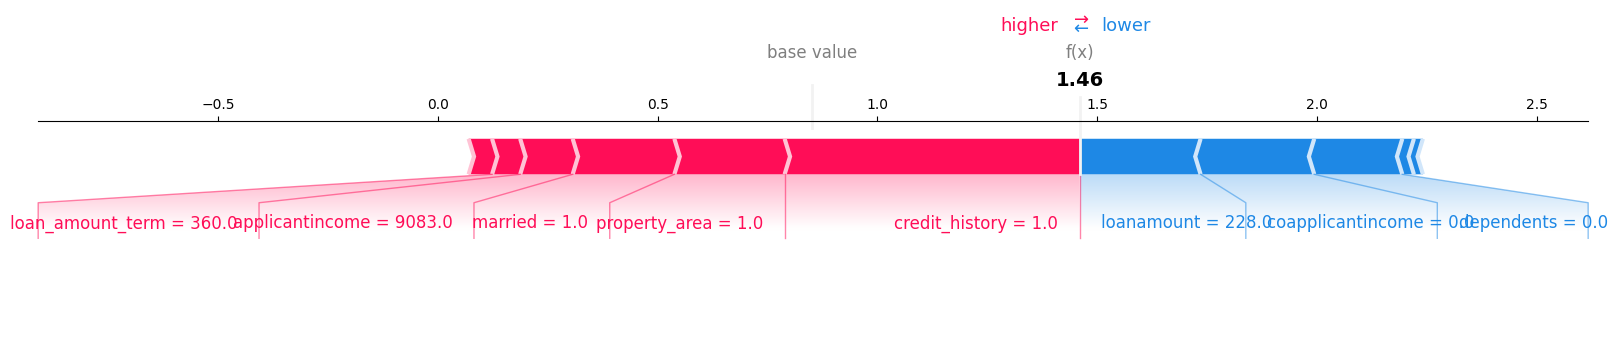

In [10]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Feature Importance Summary
print("Summary Plot: Which features matter most globally?")
shap.summary_plot(shap_values, X_test)

# Plot 2: Single Prediction Explanation
# We explain the first person in our test set
print("\nWaterfall Plot: Explaining a specific loan decision...")
# For XGBoost, shap_values might be a list or a single array depending on version
# If this errors, use: shap.plots.waterfall(explainer(X_test)[0])
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True)